## 1.4 Interpolation par intervalles

### Interpolation linéaire par morceaux

Soit $f: \mathbf [a,b] \rightarrow R$ continue et $a=x_0<\ldots<x_n=b$. 

On choisit une partition de $[a,b]$ en $N$ sous-intervalles de la forme $[x_i, x_{i+1}], i=0,...,N-1]$.
Sur chaque sous-intervalle, on fait une interpolation de degré 1 avec les 2 noeuds $x_i, x_{i+1}$.
Sur chaque sous-intervalle $I_i=[x_i, x_{i+1}]$, on interpole $f_{\mid I_i}$ par
un polynôme de degré 1. Le polynôme par morceaux (polynôme
  composite) qu'on obtient est noté $\Pi_1^H f(x)$ et on a:
$$\Pi_1^H f(x) = f(x_i) + \dfrac{f(x_{i+1}) - f(x_i)}{x_{i+1} - x_i}
(x - x_i) \quad \text{pour } x\in [x_i, x_{i+1}]$$

Dans le cas de données $y$, cela s'écrit
$$\Pi_1^H (x) = y_i + \dfrac{y_{i+1} - y_i}{x_{i+1} - x_i}
(x - x_i) \quad \text{pour } x\in [x_i, x_{i+1}]$$

Le choix le plus simple est le suivant :

* on pose $H = \frac{b-a}{N}$
* ensuite $x_i = a + iH$ pour $i=0,...,N$



In [2]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt

from InterpolationLib import PiecewiseLinearInterpolation as  PiH1


La fonction `PiH1` implémente l'interpolation linéaire par morceaux pour des points équidistribués

```python
def PiecewiseLinearInterpolation(a,b,N,f,z):
    # the input variables are:
    # a,b : x[0] = a, x[n] = b
    # f : the corresponding data at the points x
    # z : where to evaluate the function
```
    
    

### Exercice

Soient $x_k, k=0,...,4$ des points équidistribués sur l'intervalle $[1,5]$ et 
$y_k = (3.38, 3.86, 3.85, 3.59, 3.49)$
les valeurs d'une fonction en ces points. 

* Dessinez le graphe de l'interpolateur par morceaux de cette fonction
* Calculez numériquement (sur papier) la valeur de $\Pi^H_1(4.5)$ et vérifiez le résultat sur le graphique



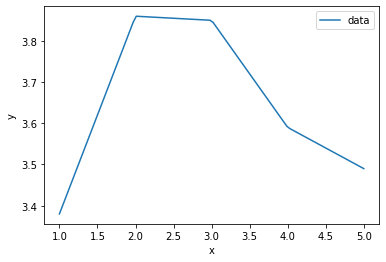

In [3]:
# intervalle d'interpolation
a = 1; b = 5

# define the vector of values at equidistributed points x
# N the number of intervals
# y the array of values
# then use PiH1(a,b,N,y,z) to compute and plot the piecewise linear interpolant

# >>> COMPLETE HERE <<<

x = np.linspace(a,b,5)
N = 4
y = np.array([3.38, 3.86, 3.85, 3.59, 3.49])
z = np.linspace(1,5,100)

plt.plot(z,PiH1(a,b,N,y,z))

plt.xlabel('x'); plt.ylabel('y')
plt.legend(['data','p(x)'])
plt.show()



### Exercice

Dessinez le graphe de la fonction de Runge et l'interpolateur linéaire par morceaux 
sur l'intervalle $[-5,5]$ pour $N=3,5,10$


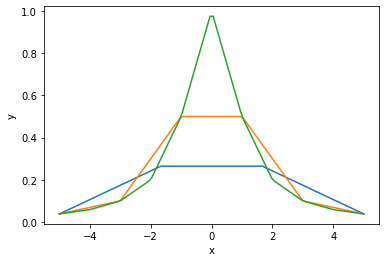

In [4]:
# interval and function
a = -5; b = 5
f = lambda x : 1/(1+x**2)

# >>> COMPLETE HERE <<<

N = [3,5,10]
z = np.linspace(-5,5,100)

for n in N :
    x = np.linspace(a,b,n+1)
    y = f(x)
    plt.plot(z,PiH1(a,b,n,y,z))

plt.xlabel('x'); plt.ylabel('y')
plt.show()

### Erreur d'interpolation linéaire par morceaux 

#### Théorème 

Soient $f\in C^{2}([a,b])$, $H = \frac{b-a}{N}$, $x_i = a + iH$ pour $i=0,...,N$.
  
Soit $E^H_1f(x) = f(x) - \Pi_1^{H} f(x)$, alors
$$\max_{x\in I}\mid E^H_1f(x) \mid\leq \dfrac{H^2}{8}\max_{x \in I} | f''(x)|.$$

**Preuve**
D'après la formule, sur chaque intervalle $I_i=[x_i,x_{i+1}]$, on a
  
$$\max_{x\in[x_i,x_{i+1}]}\mid E^H_1f(x)\mid \leq
      \dfrac{H^2}{4(1+1)}\max_{x\in I_i}\mid f''(x)\mid.$$

**Remarque**
On peut aussi montrer que, si l'on utilise un polynôme
de degré $n$ ($\geq 1$) et si l'on dénote $E^H_nf(x) = f(x) - \Pi_n^{H} f(x)$,
 dans chaque sous-intervalle $I_i$, on
trouve

$$\max_{x\in I}\mid E^H_nf(x) \mid \leq \dfrac{H^{n+1}}{4(n+1)} \max_{x \in I} |f^{(n+1)} (x)| \, .$$


### Interpolation quadratique par morceaux

Soit $f: \mathbf [a,b] \rightarrow R$ continue et $a=x_0<\ldots<x_n=b$. 
Sur chaque sous-intervalle $[x_i,x_{i+1}]$, on fait une interpolation de **degré 2** avec 
les **3 noeuds** $x_i, x_{i+\frac12}, x_{i+1}$, où $x_{i+\frac12}$ est le milieu de $[x_i,x_{i+1}]$.
Sur chaque sous-intervalle $I_i=[x_i, x_{i+1}]$, on interpole $f_{\mid I_i}$ par
un polynôme de degré 2. Le polynôme par morceaux (polynôme
  composite) qu'on obtient est noté $\Pi_2^H f(x)$ et on a:

$$\Pi_2^H f(x) = f(x_i)\varphi^{(i)}_0(x) + f(x_{i+\frac12})\varphi^{(i)}_1(x) 
    + f(x_{i+1})\varphi^{(i)}_2(x) \quad \text{pour } x\in [x_i, x_{i+1}]$$

où $\varphi^{(i)}_0(x), \varphi^{(i)}_1(x), \varphi^{(i)}_0(x)$ sont les polynômes de la base de Lagrange
associés aux noeuds $(x_i,x_{i+\frac12}, x_{i+1})$.


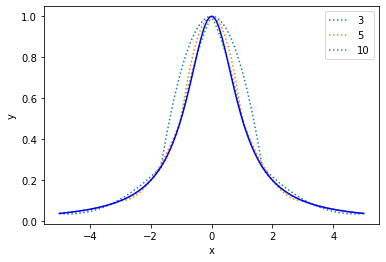

In [8]:
from InterpolationLib import PiecewiseQuadraticInterpolation as  PiH2

# intervalle et fonction
a = -5; b = 5
f = lambda x : 1/(1+x**2)

# Values of N to use
Nrange = [3,5,10]
# plotting points
z = np.linspace(-5, 5, 100)

for N in Nrange :
    plt.plot(z, PiH2(a,b,N,f,z), ':')

plt.plot(z, f(z), 'b')
plt.xlabel('x'); plt.ylabel('y'); #plt.title('data')
plt.legend(Nrange)
plt.show()



#### Exercice

Calculez l'erreur d'interpolation de la fonction de Runge dans l'intervalle $[-5,5]$ quand on utilise l'interpolation linéaire par morceaux

1. Théoriquement
2. Faites un graphique qui montre la convergence en fonction de $H=\frac{b-a}N=\frac{10}{N}$
3. Refaites le même exercice pour l'interpolation quadratique par morceaux

#### Remarque

On s'attend à ce que l'erreur soit quadratique en H. Pour le voir il faut utiliser 
des axes logarithmiques dans les deux directions.

Admettons que l'erreur converge quadratiquement vers 0 par rapport à $H$, e.g
```Python
err = lambda H : 3*H**2 + 2*H**3

```
Comment est le graphique de cette fonction dans l'intervalle $[10^{-6},1]$ ?
Que se passe-t-il si on change les axes avec `plt.xscale('log')` et  `plt.yscale('log')` ?
Quelle est la pente de `err` dans ce système ?



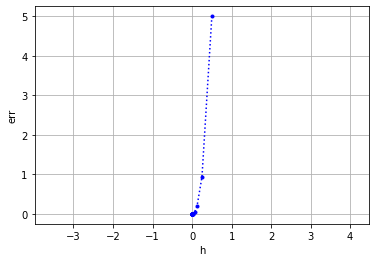

In [6]:
## Assume the error is quadratic
err = lambda H : 10*H**2 + 20*H**3

# take h has powers of 2: 2^(-20),2^(-19), ..., 2^(-1) 
h = np.power(2,np.linspace(-20, -1, 20, endpoint=True) )

plt.plot(h, err(h), 'b:.')

plt.xlabel('h'); plt.ylabel('err')

# plt.xscale('log') 
# plt.yscale('log')

plt.grid(True)
# try with and wothout equal axis
plt.axis('equal')
plt.show()

